## Library Import

In [1]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd
from statsmodels.tsa.interp.denton import dentonm
#dentonm is the standard temporal disaggregation method used by central banks when no monthly indicator is available.

## Import Monthly Data from 1st Sheet

In [116]:
file_path = 'data.xlsx'
df_monthly = pd.read_excel(file_path,sheet_name =0)
df_monthly.head()

,Date,UK_CPI_Inflation,FTSE_All_Share_Index,BoE_Policy_Rate,Brent_Crude_Oil_Spot,Gold_Price_Spot,Trade_Weighted_GBP_Index,D_GFC,D_COVID,D_Nixon
0,1965M01,4.584527,NaN,7.0,1.42,35.12,259.41,0.0,0.0,0.0
1,1965M02,4.484733,NaN,7.0,1.42,35.12,259.81,0.0,0.0,0.0
2,1965M03,4.467680,NaN,7.0,1.42,35.12,259.71,0.0,0.0,0.0
3,1965M04,5.560791,NaN,7.0,1.42,35.12,260.14,0.0,0.0,0.0
4,1965M05,5.046729,NaN,7.0,1.42,35.12,260.56,0.0,0.0,0.0


### Clean and parse monthly date

In [117]:
# Rename Date column for consistency
df_monthly = df_monthly.rename(columns={"Date": "date"})

# Convert 1985M10 → pandas datetime (month start)
df_monthly["date"] = pd.to_datetime(
    df_monthly["date"].str.replace("M", "-"),
    format="%Y-%m"
)
# Adjust to end of month
df_monthly["date"] = df_monthly["date"] + MonthEnd(0)
# Set as index
df_monthly = df_monthly.set_index("date")
df_monthly = df_monthly.dropna()
df_monthly.head()

,UK_CPI_Inflation,FTSE_All_Share_Index,BoE_Policy_Rate,Brent_Crude_Oil_Spot,Gold_Price_Spot,Trade_Weighted_GBP_Index,D_GFC,D_COVID,D_Nixon
date,,,,,,,,,
1980-02-29,19.11,263.809998,17.0,38.50,665.32,163.00,0.0,0.0,0.0
1980-03-31,19.76,240.380005,17.0,38.25,553.58,163.32,0.0,0.0,0.0
1980-04-30,21.75,249.479996,17.0,38.15,517.41,164.97,0.0,0.0,0.0
1980-05-31,21.91,243.600006,17.0,38.50,513.80,165.29,0.0,0.0,0.0
1980-06-30,20.98,269.540009,17.0,38.00,600.72,165.30,0.0,0.0,0.0


In [118]:
df_monthly.tail()

,UK_CPI_Inflation,FTSE_All_Share_Index,BoE_Policy_Rate,Brent_Crude_Oil_Spot,Gold_Price_Spot,Trade_Weighted_GBP_Index,D_GFC,D_COVID,D_Nixon
date,,,,,,,,,
2025-06-30,3.6,4772.77979,4.25,71.45,3352.66,85.9689,0.0,0.0,0.0
2025-07-31,3.8,4957.18018,4.00,70.95,3340.15,85.0417,0.0,0.0,0.0
2025-08-31,3.8,4972.79004,4.00,68.20,3368.03,84.9973,0.0,0.0,0.0
2025-09-30,3.8,5061.72998,4.00,67.95,3667.68,84.9076,0.0,0.0,0.0
2025-10-31,3.6,5240.20996,4.00,64.65,4058.33,84.4272,0.0,0.0,0.0


In [119]:
df_monthly.index.min(), df_monthly.index.max()


(Timestamp('1980-02-29 00:00:00'), Timestamp('2025-10-31 00:00:00'))

## Import Quarterly GDP and apply Denton Method to get Monthly GDP estimates

In [120]:
df_gdp_q = pd.read_excel(
    file_path,
    sheet_name=1
)
df_gdp_q.columns = df_gdp_q.columns.str.strip()
df_gdp_q.head()

,Time,GDP_CVM
0,1965 Q1,199276
1,1965 Q2,199419
2,1965 Q3,200957
3,1965 Q4,202259
4,1966 Q1,202588


### Parse Quarterly Date

In [121]:
# Rename columns
df_gdp_q = df_gdp_q.rename(
    columns={"Time": "date", "GDP_CVM": "gdp"}
)
df_gdp_q['date'] = df_gdp_q['date'].str.replace(' ', '')
# Convert "1965 Q3" → quarterly Period → timestamp
df_gdp_q["date"] = (
    pd.PeriodIndex(df_gdp_q["date"], freq="Q")
      .to_timestamp()
)

# Set index
df_gdp_q = df_gdp_q.set_index("date")

# Drop NA
df_gdp_q = df_gdp_q.dropna()
df_gdp_q.head()

,gdp
date,
1965-01-01,199276
1965-04-01,199419
1965-07-01,200957
1965-10-01,202259
1966-01-01,202588


### Convert Quarterly GDP → Monthly (Denton Proportional)

In [122]:
gdp_q = df_gdp_q["gdp"].values
# Monthly length = quarterly observations × 3


indicator_monthly = np.ones(len(gdp_q) * 3)

gdp_monthly_values = dentonm(
    indicator=indicator_monthly,  # HIGH-frequency indicator
    benchmark=gdp_q,              # LOW-frequency benchmark
    freq="qm"                     # quarterly → monthly
)

monthly_index = pd.date_range(
    start=df_gdp_q.index.min(),
    periods=len(gdp_monthly_values),
    freq="M"
)

df_gdp_m = pd.DataFrame(
    gdp_monthly_values,
    index=monthly_index,
    columns=["GDP_CVM"]
)
df_gdp_m.head()

/var/folders/by/cj_yxdq15vj554pxj84sd9h00000gn/T/ipykernel_84182/1270590593.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_index = pd.date_range(


,GDP_CVM
1965-01-31,66435.220412
1965-02-28,66427.805103
1965-03-31,66412.974485
1965-04-30,66390.728557
1965-05-31,66446.870657


In [123]:
len(df_gdp_m), len(df_monthly)

(726, 549)

## Combine datasets on inner join

In [124]:
df_combined = pd.concat([df_gdp_m, df_monthly], axis=1, join='inner')
df_combined.head()

,GDP_CVM,UK_CPI_Inflation,FTSE_All_Share_Index,BoE_Policy_Rate,Brent_Crude_Oil_Spot,Gold_Price_Spot,Trade_Weighted_GBP_Index,D_GFC,D_COVID,D_Nixon
1980-02-29,96833.690437,19.11,263.809998,17.0,38.50,665.32,163.00,0.0,0.0,0.0
1980-03-31,96112.077682,19.76,240.380005,17.0,38.25,553.58,163.32,0.0,0.0,0.0
1980-04-30,95267.393615,21.75,249.479996,17.0,38.15,517.41,164.97,0.0,0.0,0.0
1980-05-31,94783.927387,21.91,243.600006,17.0,38.50,513.80,165.29,0.0,0.0,0.0
1980-06-30,94661.678998,20.98,269.540009,17.0,38.00,600.72,165.30,0.0,0.0,0.0


In [125]:
len(df_gdp_m), len(df_monthly), len(df_combined)

(726, 549, 545)

In [126]:
df_combined

,GDP_CVM,UK_CPI_Inflation,FTSE_All_Share_Index,BoE_Policy_Rate,Brent_Crude_Oil_Spot,Gold_Price_Spot,Trade_Weighted_GBP_Index,D_GFC,D_COVID,D_Nixon
1980-02-29,96833.690437,19.11,263.809998,17.00,38.50,665.32,163.0000,0.0,0.0,0.0
1980-03-31,96112.077682,19.76,240.380005,17.00,38.25,553.58,163.3200,0.0,0.0,0.0
1980-04-30,95267.393615,21.75,249.479996,17.00,38.15,517.41,164.9700,0.0,0.0,0.0
1980-05-31,94783.927387,21.91,243.600006,17.00,38.50,513.80,165.2900,0.0,0.0,0.0
1980-06-30,94661.678998,20.98,269.540009,17.00,38.00,600.72,165.3000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2025-02-28,234542.492120,3.70,4754.319820,4.50,75.16,2894.73,86.8391,0.0,0.0,0.0
2025-03-31,234877.241684,3.40,4623.620120,4.50,72.57,2983.25,84.8896,0.0,0.0,0.0
2025-04-30,235042.514887,3.50,4594.049800,4.25,67.75,3217.64,84.6692,0.0,0.0,0.0
2025-05-31,235152.697023,3.40,4759.540040,4.25,64.21,3309.49,85.6975,0.0,0.0,0.0


### Addressing Issue of Trade Weighted GBP Index


<Axes: title={'center': 'Trade Weighted GBP Index vs GDP_CVM'}>

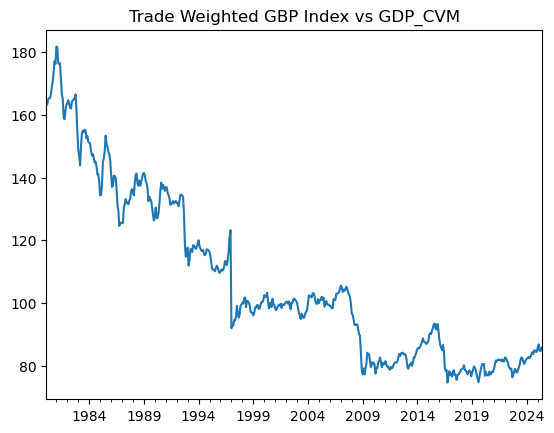

In [127]:
df_combined['Trade_Weighted_GBP_Index'].plot(title='Trade Weighted GBP Index vs GDP_CVM')

In [128]:
df= df_combined.copy()
splice_date = '1997-01-31'
df['Trade_Weighted_GBP'] = df['Trade_Weighted_GBP_Index'].loc[splice_date:]
df['Narrow_NEER_GBP'] = df['Trade_Weighted_GBP_Index'].loc[:splice_date]
df['Narrow_NEER_GBP'].loc[splice_date] = np.nan

/var/folders/by/cj_yxdq15vj554pxj84sd9h00000gn/T/ipykernel_84182/610373299.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Narrow_NEER_GBP'].loc[splice_date] = np.nan


In [129]:
df.loc['1996-10-31':'1997-04-28', ['Trade_Weighted_GBP_Index', 'Trade_Weighted_GBP', 'Narrow_NEER_GBP']]

,Trade_Weighted_GBP_Index,Trade_Weighted_GBP,Narrow_NEER_GBP
1996-10-31,116.5200,NaN,116.52
1996-11-30,121.1200,NaN,121.12
1996-12-31,123.2200,NaN,123.22
1997-01-31,91.9770,91.9770,NaN
1997-02-28,92.9298,92.9298,NaN
1997-03-31,92.8110,92.8110,NaN


In [130]:
df["log_twi"] = np.log(df["Trade_Weighted_GBP"])
df["log_neer"] = np.log(df["Narrow_NEER_GBP"])
df["dlog_neer"] = df["log_neer"].diff()
# Anchor value at splice point
anchor_value = df.loc[splice_date, "log_twi"]

# Backcast
df.loc[df.index < splice_date, "log_twi"] = (
    anchor_value
    - df.loc[df.index < splice_date, "dlog_neer"][::-1].cumsum()[::-1]
)

df["log_gbp_index"] = df["log_twi"]
df["gbp_index"] = np.exp(df["log_gbp_index"])
df_combined['Gbp_index'] = df['gbp_index']
# df_combined.drop(columns=['Trade_Weighted_GBP_Index'],inplace=True)

df_combined.reset_index(inplace=True)
df_combined = df_combined.rename(columns={'index':'Date'})
df_combined

,Date,GDP_CVM,UK_CPI_Inflation,FTSE_All_Share_Index,BoE_Policy_Rate,Brent_Crude_Oil_Spot,Gold_Price_Spot,Trade_Weighted_GBP_Index,D_GFC,D_COVID,D_Nixon,Gbp_index
0,1980-02-29,96833.690437,19.11,263.809998,17.00,38.50,665.32,163.0000,0.0,0.0,0.0,NaN
1,1980-03-31,96112.077682,19.76,240.380005,17.00,38.25,553.58,163.3200,0.0,0.0,0.0,121.670597
2,1980-04-30,95267.393615,21.75,249.479996,17.00,38.15,517.41,164.9700,0.0,0.0,0.0,121.909460
3,1980-05-31,94783.927387,21.91,243.600006,17.00,38.50,513.80,165.2900,0.0,0.0,0.0,123.141095
4,1980-06-30,94661.678998,20.98,269.540009,17.00,38.00,600.72,165.3000,0.0,0.0,0.0,123.379957
...,...,...,...,...,...,...,...,...,...,...,...,...
540,2025-02-28,234542.492120,3.70,4754.319820,4.50,75.16,2894.73,86.8391,0.0,0.0,0.0,86.839100
541,2025-03-31,234877.241684,3.40,4623.620120,4.50,72.57,2983.25,84.8896,0.0,0.0,0.0,84.889600
542,2025-04-30,235042.514887,3.50,4594.049800,4.25,67.75,3217.64,84.6692,0.0,0.0,0.0,84.669200
543,2025-05-31,235152.697023,3.40,4759.540040,4.25,64.21,3309.49,85.6975,0.0,0.0,0.0,85.697500


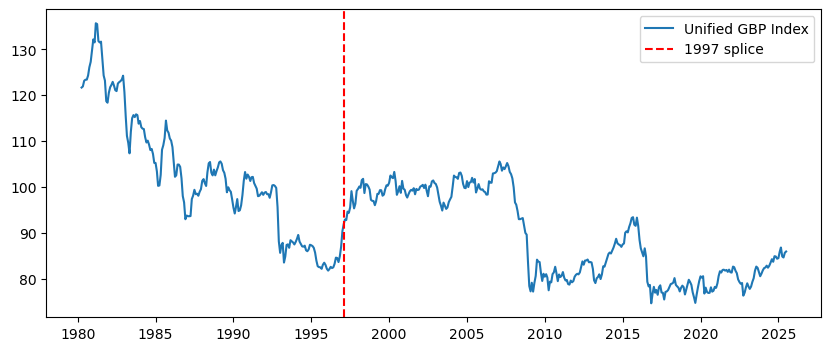

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(df_combined['Date'],df_combined["Gbp_index"], label="Unified GBP Index")
plt.axvline(pd.Timestamp(splice_date), color="red", linestyle="--", label="1997 splice")
plt.legend()
plt.show()


In [132]:
df_combined.to_csv('cleaned_dataset.csv',index=False)